## Libraries

### *Data Management & Basic Stats*

In [ ]:
import pandas as pd
import numpy as np
import os

from random import randint
from glob import glob
import pickle

from scipy.stats import zscore

### *Neuroimaging Stats*

In [ ]:
import nibabel as nib
from nilearn import image as nimg

from neuromaps.transforms import mni152_to_fslr
from neuromaps.nulls import alexander_bloch
from neuromaps.stats import compare_images

from enigmatoolbox.utils.parcellation import parcel_to_surface

### *Plotting*

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns

In [ ]:
gradfiles = glob(os.path.join(os.getcwd(), 'gradientmaps_mni/volume.cort.*.nii.gz'))
grads = pd.DataFrame()
for i in range(len(gradfiles)):
    gradfile = nib.load(gradfiles[i])
    gradheader = gradfile.header

    graddata = gradfile.get_fdata()

    grad_1D = graddata.flatten()

    grads['gradient' + str(i + 1)] = grad_1D


In [ ]:
masterset = pd.read_csv('master_set.csv')

grad_iccs  = (
    masterset.filter(regex = r'(commspsych|gradient|icc_)', axis = 1)
    .groupby(['commspsych']).mean()
)

task_scores = (
    masterset.filter(regex = r'(commspsych|^PC)')
    .groupby(['commspsych']).mean()
)

,PC1,PC2,PC3,PC4
commspsych,,,,
0B,-0.350600,0.469509,-0.168658,-0.111991
1B,-0.499410,-0.081285,0.290167,-0.051716
2B-Face,-0.331583,-0.044899,-0.003609,0.118665
2B-Scene,-0.484232,-0.028631,0.108974,-0.115589
Documentary,-0.379712,-0.174342,-0.777161,0.676690
EasyMath,-0.314895,-0.173467,0.707120,-0.557877
FingerTap,-0.582230,0.242580,-0.461172,-0.266821
Friend,1.284726,-0.523065,0.240176,0.669515
GoNoGo,-0.712291,0.279042,-0.420284,-0.414243


In [ ]:
orange = '#fd8d3c'
green = '#74c476'
blue = '#6baed6'
purple = '#9e9ac8'

bg_colors = [green, orange, orange, orange, purple, orange, green, blue, green,
             orange, blue, purple, purple, blue]
colors = ['#e5f5e0','#a63603','#e6550d','#fd8d3c','#bcbddc','#fdbe85','#31a354',
       '#9ecae1','#a1d99b','#feedde','#3182bd','#efedf5','#746ab0','#deebf7']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

# Plot the scatter points
sc = ax.scatter(
    task_scores['PC1'], 
    task_scores['PC2'], 
    task_scores['PC3'],
    c = colors,
    edgecolor='black',
    s=80,
    marker="o",
    alpha=0.8,
    depthshade=True
)

# Set axis labels
ax.set_xlabel('Episodic Knowledge', labelpad=10, fontdict={'fontsize':20, 'style':'oblique'})
ax.set_ylabel('Intrusive Distraction', labelpad=10, fontdict={'fontsize':20, 'style':'oblique'})
ax.set_zlabel('Deliberate Task-Focus', labelpad=10, fontdict={'fontsize':20, 'style':'oblique'})

# Set axis limits
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.75, 0.75)
ax.set_zlim(-0.75, 0.75)

# Improve 3D view angle for better spatial separation
ax.view_init(elev=30, azim=45)

#Annotate each point with task name
for i, txt in enumerate(task_scores.index):
    ax.text(
        task_scores['PC1'][i]+0.09,
        task_scores['PC2'][i]+0.09,
        task_scores['PC3'][i]+0.09,
        txt,
        fontsize=20,
        ha='left',
        va='center',
        color=colors[i],
        fontname = 'Arial',
        fontweight = "bold"
        # backgroundcolor='white'
    ).set_path_effects([
    path_effects.withStroke(linewidth=0.5, foreground=bg_colors[i])])

plt.tight_layout()
plt.savefig('Figures/tasks_PCs.jpg')

plt.show()
plt.close()


## Generating Dot-Product Maps

In [ ]:
def getref_properties(reffile):

    ref_grad = nib.load(reffile)

    return {'shape':ref_grad.shape,
            'header':ref_grad.header,
            'affine':ref_grad.affine}

def gen_dotprod_nifti(df, file_prefix=randint(10000,99999), save = True):

    refinfo = getref_properties('gradientmaps_mni/volume.cort.0.nii.gz') 
    
    imgs = {}
    for header, column in df.items():

        icc_3Dmap = np.reshape(df[header].to_numpy(), refinfo['shape'])
        saveimg = nib.Nifti1Image(icc_3Dmap, refinfo['affine'], refinfo['header'])
        if save:
            imgpath = f'{header}_{file_prefix}_mnidot.nii.gz'
            nib.save(saveimg, imgpath)

        imgs[header] = imgpath

    return imgs

def gradproduct(corr_mtx, grads, file_prefix = randint(10000, 99999), parcellated=False, scale=False, bygrad = False, save=True):
    
    if parcellated:
        grads = pd.read_csv('gradients_parcellated.csv')
        grads = grads.iloc[:,1:]

    if scale:
        grads = grads.apply(zscore)


    dot_prod = np.dot(grads,corr_mtx.to_numpy())
    dot_prod = pd.DataFrame(dot_prod, columns=corr_mtx.columns)

    if save:
        dot_prod.to_csv(f'{file_prefix}_dotprods.csv', index = False)

    return dot_prod    
            
def dotprodmap(df, parcellation, srf_atlas, file_prefix = randint(10000, 99999)):

    for col in df:

        col_parcel = parcel_to_surface(df[col], parcellation)

        plot_cortical(array_name=col_parcel, surface_name=srf_atlas, size=(800, 400),
                    cmap='RdBu_r', color_bar=True, color_range = (-1, 1),
                    screenshot = True, filename = f'{file_prefix}_{col}_prodmap.png')

## Spin-testing

In [ ]:
def saveGifti(file_l, file_r, file_prefix):
    filepath_L = f"{file_prefix}.L.func.gii"
    filepath_R = f"{file_prefix}.R.func.gii"

    nib.save(file_l, filepath_L)
    nib.save(file_r, filepath_R)

    return filepath_L, filepath_R

def applymask(img, maskimg):
    """
    Return masked image.

    Args:
        img (nibabel image object): Image to apply mask to.
        maskimg (nibabel image object): Mask image to apply to image.

    Returns:
        Masked img.
    """
    # try to apply without reshaping
    try:
        return nimg.math_img('a*b',a=img, b=maskimg) #element wise multiplication - return the resulting map
    # if shapes don't match, reshape img
    except ValueError:
        print('Shapes of images do not match')
        print(f'mask-image shape: {maskimg.shape}, image shape {img.shape}')
        print('Reshaping image to mask-image dimensions...')
        img = nimg.resample_to_img(source_img=img,target_img=maskimg,interpolation='nearest')
        return nimg.math_img('a*b',a=img, b=maskimg) #element wise multiplication - return the resulting map

def spinmaps(refmaps, compmaps,
             reflab=None, complab=None,
             mask=False,
             file_prefix=randint(10000,99999),
             save=True, nulls=True, plot=True):

    results = []
    if nulls:
        null_data = {}

    for i in range(len(refmaps)):
        
        # ref = nib.load(refmaps[i])
        if mask:
            ref = applymask(ref, mask)

        ref_l, ref_r = mni152_to_fslr(refmaps[i], '32k', method = 'nearest')
        rpath_l, rpath_r = saveGifti(ref_l, ref_r, "tempref")

        refname = reflab
        if len(refmaps) > 1:
            refname = f'{reflab}_{i + 1}'

        for j in range(len(compmaps)):

            resultdict = {}

            # comp = nib.load(compmaps[j])
            if mask:
                comp = applymask(comp, mask)

            comp_l, comp_r = mni152_to_fslr(compmaps[j], '32k', method = 'nearest')
            cpath_l, cpath_r = saveGifti(comp_l, comp_r, "tempcomp")

            compname = complab
            if len(compmaps) > 1:
                compname = f'{complab}_{j + 1}'
        
            rotated = alexander_bloch((cpath_l, cpath_r), atlas='fslr', density='32k',
                                            n_perm=1000, seed=1420)
            
            corr, pval, null_dist  = compare_images((cpath_l, cpath_r), (rpath_l, rpath_r), 
                                                          nulls=rotated, return_nulls=nulls,
                                                          metric='spearmanr')

            resultdict['referent'] = refname
            resultdict['comparate'] = compname
            resultdict['corr_surf'] = corr
            resultdict['sig'] = pval
            resultdict['null_mean'] = np.mean(null_dist)
            resultdict['null_SD'] = np.std(null_dist) 
            
            if nulls:
                null_data[f'{refname}_{compname}'] = null_dist

            results.append(resultdict)

            print(f"{refname} x {compname}: R = {round(corr, 2)}, p = {str(round(pval, 3))[1:]}")
            print("*" * 20)

    
    results_df = pd.DataFrame(results)
    if save:
        results_df.to_csv(f'{file_prefix}_spinres.csv', index = False)

        if nulls:
            # # Save null_dists to a file
            with open(f'{file_prefix}_nulldata.pkl', 'wb') as f:
                pickle.dump(null_data, f)

    if plot:
        
        plotspins(refmaps, compmaps,
                  results_df, null_data,
                  file_prefix)
        
    return results_df

def plotspins(refmaps, compmaps,
              results, nulldata,
              xmin=-0.75, xmax=0.75,
              file_prefix=randint(10000,99999),
              style = "boxy"):

    fig, axes = plt.subplots(len(compmaps), len(refmaps),
                             figsize=(15, 15), squeeze = False)  # Adjust figsize as needed

    for i, comp in enumerate(results['comparate'].unique()):
        for j, ref in enumerate(results['referent'].unique()):

            corr = results[(results['comparate'] == comp) & (results['referent'] == ref)]['corr_surf'].values[0]
            nulls = nulldata[f'{ref}_{comp}']  # Use the matching key to access null distribution
            pval = results[(results['comparate'] == comp) & (results['referent'] == ref)]['sig'].values[0]


            label = f'r = {round(corr, 2)}'

            if pval < .001:
                label = label + "***"
            elif pval < .01:
                label = label + "**"
            elif pval < .05:
                label = label + "*"

            if style == "boxy":
                axes[i, j].hist(nulls, bins=20, density=True)
                axes[i, j].axvline(corr, ls="--", color="r")

            elif style == "kde":
                
                axes[i, j].axvline(x=results['corr_surf'], color="green", linestyle="dotted", label="Real Correlation")
                sns.kdeplot(data=nulldata, ax=axes[i, j], color="grey", fill=True, alpha=0.5, linewidth=0, label="Null Correlations")

            axes[i, j].set_xlim(xmin, xmax)
            if corr > 0 :
                axes[i, j].text(.95, .99, label, ha = 'right', va = 'top', fontstyle = 'italic', fontweight = 'bold', transform = axes[i,j].transAxes)
            else :
                axes[i, j].text(.01, .99, label, ha = 'left', va = 'top', fontstyle = 'italic', fontweight = 'bold', transform = axes[i,j].transAxes)


            if i == 0:
                axes[i, j].set_title(ref.replace("_", " "))
            if j == 0:
                axes[i, j].set_ylabel(comp.replace("_", " "))

    plt.tight_layout()
    plt.savefig(f'{file_prefix}_spintest.svg')
    plt.show()
    plt.close()

def plotspin(reflab, complab,
               results, nulldata,
               file_prefix=randint(10000, 99999)):
    
    fig, ax = plt.subplots(1, 1)  # Adjust figsize as needed

    ax.axvline(x=results['corr_surf'], color="green", linestyle="dotted", label="Real Correlation")
    
    # plot null correlations as a density plot (kde)
    sns.kdeplot(data=nulldata, ax=ax, color="grey", fill=True, alpha=0.5, linewidth=0, label="Null Correlations")
    
    # set title
    ax.set_title(f"{reflab} x {complab}")
    # set x and y labels
    ax.set_ylabel("Density")
    ax.set_xlabel("Correlation")
    ax.legend().set_visible(True)

    fig.tight_layout()

    plt.savefig(f'{file_prefix}_spin.png')
    plt.show()
    plt.close()


## Generating dot-products based on ICCs/task for each PC

#### *Generating Dot-Products*


In [ ]:
icc_coefs = pd.read_csv('regression_summary_z.csv')

icc_coefs = icc_coefs.iloc[:, 0:3]


coef_mtx = icc_coefs.pivot(index="gradient",
        columns="Component",
        values="median_slope")

regression_prods = gradproduct(coef_mtx, grads, file_prefix = 'parcel_reg', scale = True)

prodpaths = gen_dotprod_nifti(regression_prods, file_prefix="parcel_reg")


## Computing MDN Similarity

In [193]:
corrs = pd.read_csv('gradicc_regression_z.csv')
corrs = corrs.drop(labels=["intercept"], axis = 1)

corrs_wide = pd.wide_to_long(corrs, stubnames="g", i=["iter","Component"], j="gradient")
corrs_wide = corrs_wide.pivot_table(index=["Component", "gradient"], columns="iter", values="g").reset_index()


In [ ]:
ref_l, ref_r = mni152_to_fslr('MDN maps/NiftiVolume.nii.gz', '32k', method = 'nearest')

ref_path_L = "tempref.L.func.gii"
ref_path_R = "tempref.R.func.gii"

nib.save(ref_l, ref_path_L)
nib.save(ref_r, ref_path_R)

def boot_imgcorrs(col):

    print(col)
    
    compdict = {}

    col = corrs_wide.pivot(index = 'gradient', columns = 'Component', values = col)

    gradprods = gradproduct(col, grads, scale = True, save = False)
    prodniftis = gen_dotprod_nifti(gradprods, save = True, file_prefix='tempfile')

    for prod in prodniftis:
        prod_l, prod_r = mni152_to_fslr(prodniftis[prod], '32k', method = 'nearest')

        prod_path_L = "tempprod.L.func.gii"
        prod_path_R = "tempprod.R.func.gii"
        nib.save(prod_l, prod_path_L)
        nib.save(prod_r, prod_path_R)

        corr = compare_images((prod_path_L, prod_path_R), (ref_path_L, ref_path_R), metric='spearmanr')
        compdict[prod] = corr

    return compdict

results = {col: boot_imgcorrs(col) for col in corrs_wide.columns if col not in ['Component', 'gradient']}
results_df = pd.DataFrame(results)

results_df.to_csv('regression_mdnsimilarity_z.csv', index = False)

## Run and plot spin-tests

In [ ]:
ref_template = 'MDN maps/NiftiVolume.nii.gz'
refmaps = sorted(list(glob(ref_template)))

comp_template = 'PC*_resamp_reg_mnidot.nii.gz'
compmaps = sorted(list(glob(comp_template)))

spins = spinmaps(refmaps, compmaps,
                 reflab = "MDN", complab = "icc_PC",
                 file_prefix = "mdn_reg")

In [ ]:
results = pd.read_csv('mdn_reg_spinres.csv')

with open('mdn_reg_nulldata.pkl', 'rb') as f:
    nulldata = pickle.load(f)

plotspins(refmaps, compmaps, results, nulldata, xmin = -0.5, xmax = 0.5, file_prefix = "mdn_reg")

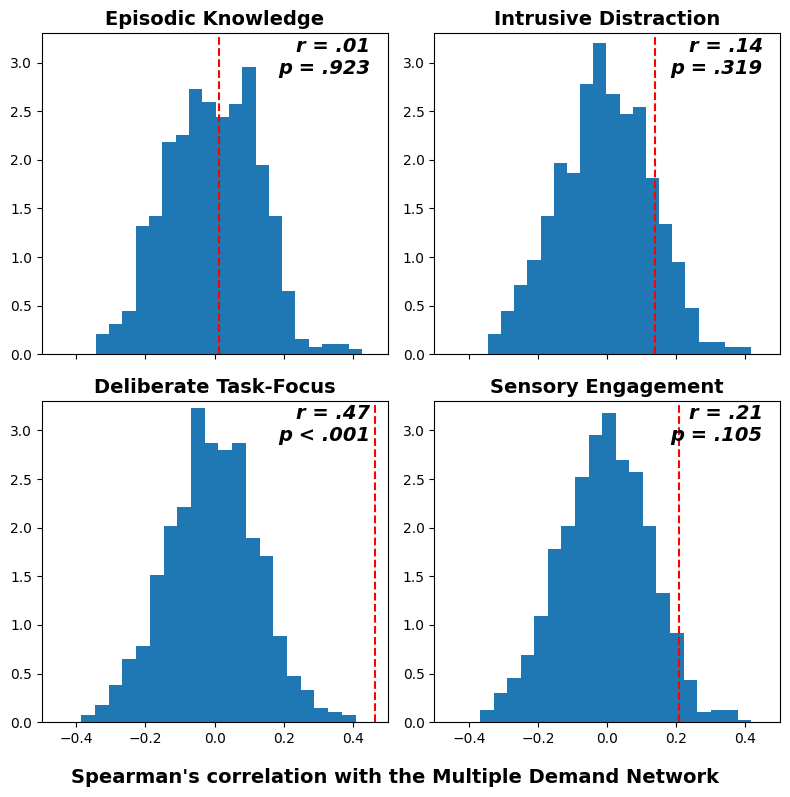

In [ ]:
labeldict = {'icc_PC_1':'Episodic Knowledge', 'icc_PC_2':'Intrusive Distraction', 'icc_PC_3':'Deliberate Task-Focus', 'icc_PC_4':'Sensory Engagement'}

fig, axes = plt.subplots(2, 2, figsize=(8, 8), squeeze = False, sharex=True)  # Adjust figsize as needed

for i, comp in enumerate(results['comparate'].unique()):

    corr = results[(results['comparate'] == comp) & (results['referent'] == "MDN")]['corr_surf'].values[0]
    nulls = nulldata[f'MDN_{comp}']  # Use the matching key to access null distribution
    pval = results[(results['comparate'] == comp) & (results['referent'] == "MDN")]['sig'].values[0]

    if pval < .001:
        pval = "p < .001"
    else:
        pval = f"p = {round(pval, 3)}"
        pval = pval.replace("0", "", 1)

    label = f"r = {str(round(corr, 2)).replace("0", "", 1)}\n{pval}"

    if i <= 1:
        row = 0
        col = i

    else:
        row = 1
        col = i - 2

    axes[row, col].hist(nulls, bins=20, density=True)
    axes[row, col].axvline(corr, ls="--", color="r")


    axes[row, col].set_xlim(-0.5, 0.5)
    axes[row, col].set_ylim(0, 3.3)
    if corr > 0 :
        axes[row, col].text(.95, .99, label, ha = 'right', va = 'top', fontstyle = 'italic', fontweight = 'bold', fontsize = 14,  transform = axes[row, col].transAxes)
    else :
        axes[row, col].text(.01, .99, label, ha = 'left', va = 'top', fontstyle = 'italic', fontweight = 'bold', fontsize = 14, transform = axes[row, col].transAxes)


    axes[row, col].set_title(labeldict[comp], fontsize = 14, fontweight = "bold") 
    axes[row, col].set_ylabel("")

fig.supxlabel("Spearman's correlation with the Multiple Demand Network", ha='center', fontsize = 14, fontweight = "bold")


plt.tight_layout()
plt.savefig('mdn_reg_spintest.svg')
plt.show()
plt.close()